In [2]:
import pandas as pd

pbdb = pd.read_csv(
    r"F:\EARTH_SYSTEM_ML_PROJECT\data\raw\pbdb\pbdb_fossils.csv",
    low_memory=False
)

pbdb.head()

,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,formation,geological_group,member,lithdescript,lithology1,lithification1,minor_lithology1,lithology2,lithification2,minor_lithology2
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,NaN,Bracklesham,NaN,NaN,sandstone,NaN,NaN,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,NaN,Bracklesham,NaN,NaN,sandstone,NaN,NaN,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,Tuchengzi,NaN,NaN,purple-grey sediments representing a river-facies,mudstone,NaN,NaN,NaN,NaN,NaN
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Yixian,Jehol,Jianshangou,NaN,siltstone,NaN,NaN,NaN,NaN,NaN
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Yixian,Jehol,Jianshangou,NaN,siltstone,NaN,NaN,NaN,NaN,NaN


In [4]:
print(pbdb.head())

   occurrence_no record_type  reid_no flags  collection_no  \
0          41524         occ      NaN   NaN           3257   
1          41580         occ      NaN   NaN           3256   
2         130209         occ      NaN   NaN          10755   
3         130294         occ      NaN   NaN          10764   
4         130295         occ      NaN   NaN          10764   

                              identified_name identified_rank  identified_no  \
0                                 Aves indet.           class            NaN   
1                                 Aves indet.           class            NaN   
2  Chaoyangosaurus liaosiensis n. gen. n. sp.         species        65704.0   
3    Protarchaeopteryx robusta n. gen. n. sp.         species            NaN   
4             Caudipteryx zoui n. gen. n. sp.         species            NaN   

  difference              accepted_name  ...  formation  geological_group  \
0        NaN                       Aves  ...        NaN       Brackle

In [6]:
taxon_col = "accepted_name" if "accepted_name" in pbdb.columns else "identified_name"

In [7]:
pbdb.columns

Index(['occurrence_no', 'record_type', 'reid_no', 'flags', 'collection_no',
       'identified_name', 'identified_rank', 'identified_no', 'difference',
       'accepted_name', 'accepted_rank', 'accepted_no', 'early_interval',
       'late_interval', 'max_ma', 'min_ma', 'reference_no', 'lng', 'lat',
       'cx_int_no', 'formation', 'geological_group', 'member', 'lithdescript',
       'lithology1', 'lithification1', 'minor_lithology1', 'lithology2',
       'lithification2', 'minor_lithology2'],
      dtype='object')

In [8]:
import pandas as pd

pbdb = pd.read_csv(r"F:\EARTH_SYSTEM_ML_PROJECT\data\raw\pbdb\pbdb_fossils.csv",
                   low_memory=False)

# choose best taxon column
taxon_col = "accepted_name" if "accepted_name" in pbdb.columns else "identified_name"

# drop missing time
pbdb = pbdb.dropna(subset=["early_interval"])

# build stage-level dataset
fossil = pbdb.groupby("early_interval").agg(
    taxon_richness=(taxon_col, "nunique"),
    occurrence_count=("occurrence_no", "count"),
    collection_count=("collection_no", "nunique"),
    mean_age=("min_ma", "mean"),
    max_age=("max_ma", "mean"),
).reset_index()

fossil.rename(columns={"early_interval": "stage"}, inplace=True)

fossil.head()

,stage,taxon_richness,occurrence_count,collection_count,mean_age,max_age
0,Aalenian,25,47,26,169.546809,174.70
1,Alaunian,12,26,10,209.915385,215.38
2,Albian,110,394,234,99.429695,113.20
3,Altonian,33,78,17,15.900000,18.70
4,Anisian,18,46,31,238.147739,246.70


In [10]:
geo = pbdb.groupby("early_interval").agg(
    lat_mean=("lat", "mean"),
    lng_mean=("lng", "mean"),
).reset_index()

geo.rename(columns={"early_interval": "stage"}, inplace=True)

fossil = fossil.merge(geo, on="stage", how="left")

In [11]:
print("Total occurrences:", len(pbdb))
print("Unique taxa:", pbdb["accepted_name"].nunique())
print("Time bins:", pbdb["early_interval"].nunique())

Total occurrences: 37790
Unique taxa: 6167
Time bins: 253


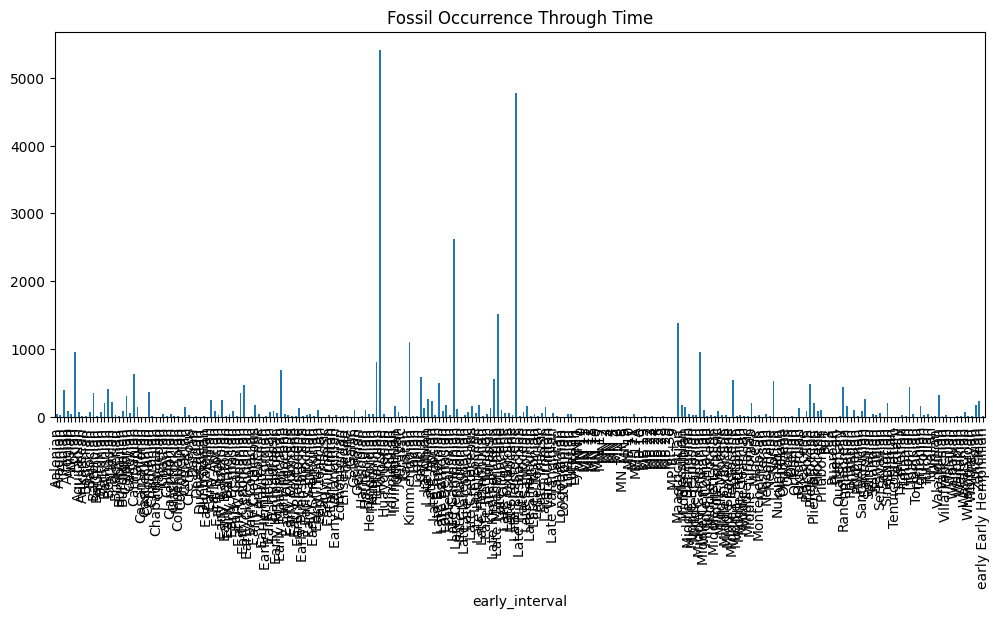

In [12]:
import matplotlib.pyplot as plt

trend = pbdb.groupby("early_interval")["occurrence_no"].count()

trend.plot(kind="bar", figsize=(12,5), title="Fossil Occurrence Through Time")
plt.show()